# Librerías

In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.integrate import dblquad, quad
from scipy.integrate import solve_ivp, simpson

In [2]:
mpl.rc('figure', figsize=(12, 6))
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')
mpl.rc('font', size = '14')
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14)
mpl.rcParams['mathtext.fontset'] = 'stix'

# Funciones

Para un modelo de preheating con $V(\phi) = \lambda \phi^4$ tenemos que las ecuaciones dinámicas adimensionales para el background son:

$$\begin{cases}
    \displaystyle \frac{d^2 \tilde{\phi}}{d \tilde{t}^2} + \frac{3}{a} \frac{d a}{d \tilde{t}} \frac{d \tilde{\phi}}{d \tilde{t}} + \tilde{\phi}^3 &= 0  \\ \\
    \displaystyle \frac{d^2 a}{d \tilde{t}^2} + \frac{a}{3} \left[ \left( \frac{d \tilde{\phi}}{d \tilde{t}} \right)^2 - \frac{\tilde{\phi}^4}{4} \right] &= 0
\end{cases} \tag{1}$$

Y para las perturbaciones, las ecuaciones adimensionales son:

$$\begin{cases}
    \displaystyle \frac{d^2 \delta \tilde{\phi}_k}{d \tilde{t}^2} + \frac{3}{a} \frac{d a}{d \tilde{t}} \frac{d \tilde{\phi}_k}{d \tilde{t}} + \left( \frac{\tilde{k}^2}{a^2} + 3 \tilde{\phi}^2 \right) \delta \tilde{\phi}_k &= 0\\
    \displaystyle \frac{d^2 \tilde{\chi}_k}{d \tilde{t}^2} + \frac{3}{a} \frac{d a}{d \tilde{t}} \frac{d \tilde{\chi}_k}{d \tilde{t}} + \left( \frac{\tilde{k}^2}{a^2} + g^2 \tilde{\phi}^2 \right) \tilde{\chi}_k &= 0
\end{cases} \tag{2}$$

In [3]:
"""Floquet"""

# Matriz de monodromía y calculo de los coeficientes de Floquet
def mu_lphi4(k, q, y0, Tosc):
    phi0, phi_dot0 = y0

    def pert(t, y, k, q):
        phi, phi_dot, chi_k, chi_dot_k = y
        phi_ddot = - phi**3
        chi_ddot_k = - (k**2 + q * phi**2) * chi_k
        return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k]

    t_span = (0, Tosc)

    sol1 = solve_ivp(pert, t_span, [phi0, phi_dot0, 1.0, 0.0], t_eval=[Tosc], method='RK45', rtol=1e-6, args=(k, q))
    y_final1 = sol1.y[:, -1]

    sol2 = solve_ivp(pert, t_span, [phi0, phi_dot0, 0.0, 1.0], t_eval=[Tosc], method='RK45', rtol=1e-6, args=(k, q))
    y_final2 = sol2.y[:, -1]

    M = np.array([
        [y_final1[2], y_final2[2]],
        [y_final1[3], y_final2[3]]
    ])

    tr_M = np.trace(M)
    argument = np.abs(tr_M / 2.0)

    if argument > 1.0:
        mu = np.arccosh(argument) / Tosc
        return mu
    else:
        return 0.0

# Calculo del periodo de oscilación del inflatón en el potencial lphi4
def oscilation(E):
    def integrand(phi):
        V = 0.25 * phi**4
        return 1.0 / np.sqrt(2 * (E - V))
    phimax = (4*E)**(1/4)
    integral, _ = quad(integrand, 0, phimax)
    Tosc = 4*integral
    return Tosc

# Guardar los datos en un archivo CSV
def save_csv(qs, Aks, mu, filename='results'):
    output = np.zeros((len(Aks)+1, len(qs)+1))
    output[0, 1:] = qs
    output[1:, 0] = Aks
    output[1:, 1:] = np.real(mu)
    np.savetxt(f"{filename}.csv", output, delimiter=",")

In [4]:
"""Dinámica"""

# Dinamica sin expansión del universo para el modelo lphi4
def pert(t, y, k, q):
    phi, phi_dot, chi_k, chi_dot_k = y
    phi_ddot = - phi**3
    chi_ddot_k = - (k**2 + q * phi**2) * chi_k
    return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k]

# Dinamica con expansión del universo para el modelo lphi4
def pert_exp(t, y, k, q):
    phi, phi_dot, chi_k, chi_dot_k, a, a_dot = y

    # Evolución de a(t)
    a_ddot = - a/3 * (phi_dot**2 - phi**4/4)
    H = a_dot/a
    
    # Ecuación para φ
    phi_ddot = -3 * H * phi_dot - phi **3
    
    # Ecuaciones para χ_k
    chi_ddot_k = - 3 * H * chi_dot_k - (k ** 2 / a**2 + q * phi**2) * chi_k 
    
    return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k, a_dot, a_ddot]

# Número de partículas producidas en el modo k
def number(k, q, phi, chik, chidot, a):
    omega_k = np.sqrt(k**2/a**2 + q * phi**2)
    nk = omega_k / 2 * ( (np.abs(chidot)/omega_k)**2 + np.abs(chik)**2 )
    return nk

#-------------------------------------------------------------------------------------------------------------------------------------
"""Condiciones iniciales"""
def CI(k, q):
    # Background
    phi0 = 1
    phi_dot0 = phi0**2/np.sqrt(2)

    # Perturbaciones
    Omega_chi = np.sqrt(k**2 + q * phi0**2)
    chi_k0 = 0 #1/(np.sqrt(2 * Omega_chi))
    chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_chi))) #np.sqrt(Omega_chi/2)

    y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0]
    return y0

def CI_exp(k, q):
    # Background
    phi0 = 1
    phi_dot0 = phi0**2/np.sqrt(2)
    areh = 1
    a_dot0 = np.sqrt( (phi_dot0**2/2 + phi0**4/4) / 3 ) * areh

    # Perturbaciones
    Omega_chi = np.sqrt(k**2 + q * phi0**2)
    chi_k0 = 0 #1/(np.sqrt(2 * Omega_chi))
    chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_chi))) #np.sqrt(Omega_chi/2)

    y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0, areh, a_dot0]
    return y0

#-------------------------------------------------------------------------------------------------------------------------------------

"""Espectro de potencias"""

def Pchi(chi_k, k):
    return (k**3 / (2 * np.pi**2)) * (np.abs(chi_k)**2)

# Dinámica de los campos

## Análisis Floquet

### Cálculo Floquets

In [5]:
# Verifico si el archivo de inestabilidades existe, sino lo armo
nombre = "Floquet"

if not os.path.exists(nombre + ".csv"):
    phi0 = 1
    phi_dot0 = phi0**2/np.sqrt(2)

    y0 = (phi0, phi_dot0)
    E = 0.5 * phi_dot0**2 + 0.25 * phi0**4

    qs = np.linspace(0, 25, 300)
    ks = np.logspace(-2, 2, 300)

    # Q, K = np.meshgrid(qs, ks)
    mu = np.zeros((len(ks), len(qs)), dtype=complex)
    Tosc = oscilation(E)

    for i, q in enumerate(tqdm(qs)):
        for j, k in enumerate(ks):
            mu[j, i] = mu_lphi4(k, q, y0, Tosc)

    # Guardemos los resultados en un archivo CSV
    save_csv(qs, ks, mu, filename = nombre)
    
else:
    data = np.loadtxt(nombre + ".csv", delimiter=",")
    qs = data[0, 1:]
    ks = data[1:, 0]
    mu = data[1:, 1:]

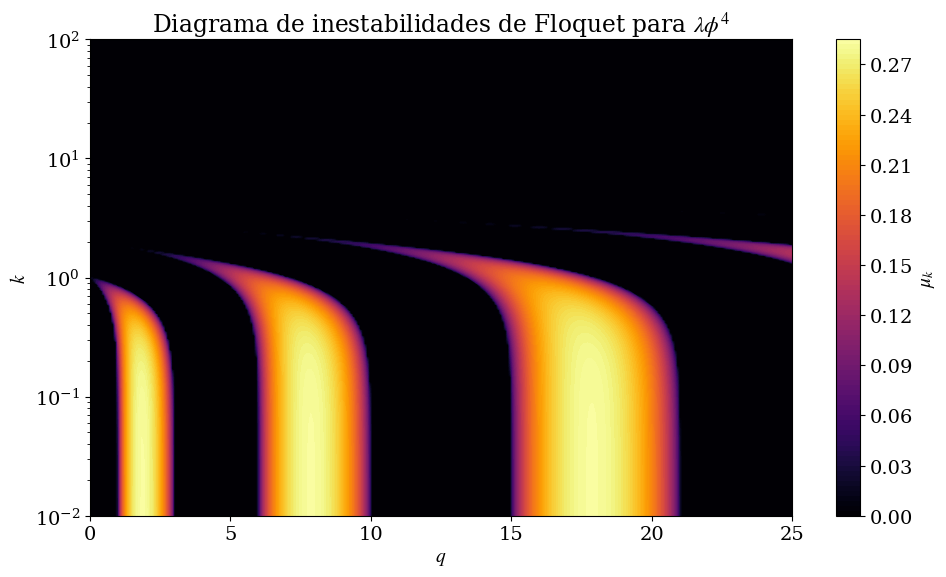

In [6]:
# Ahora grafiquemos el diagrama de inestabilidades
plt.figure(figsize=(10, 6))
plt.contourf(qs, ks, np.real(mu), levels=100, cmap='inferno')
plt.colorbar(label=r'$\mu_k$')
plt.xlabel(r'$q$')
plt.ylabel(r'$k$')
plt.yscale('log')
plt.title(r'Diagrama de inestabilidades de Floquet para $\lambda \phi^4$')
plt.tight_layout()
plt.savefig("Floquet_lphi4.pdf", format = "pdf")

### $\mu(k)$

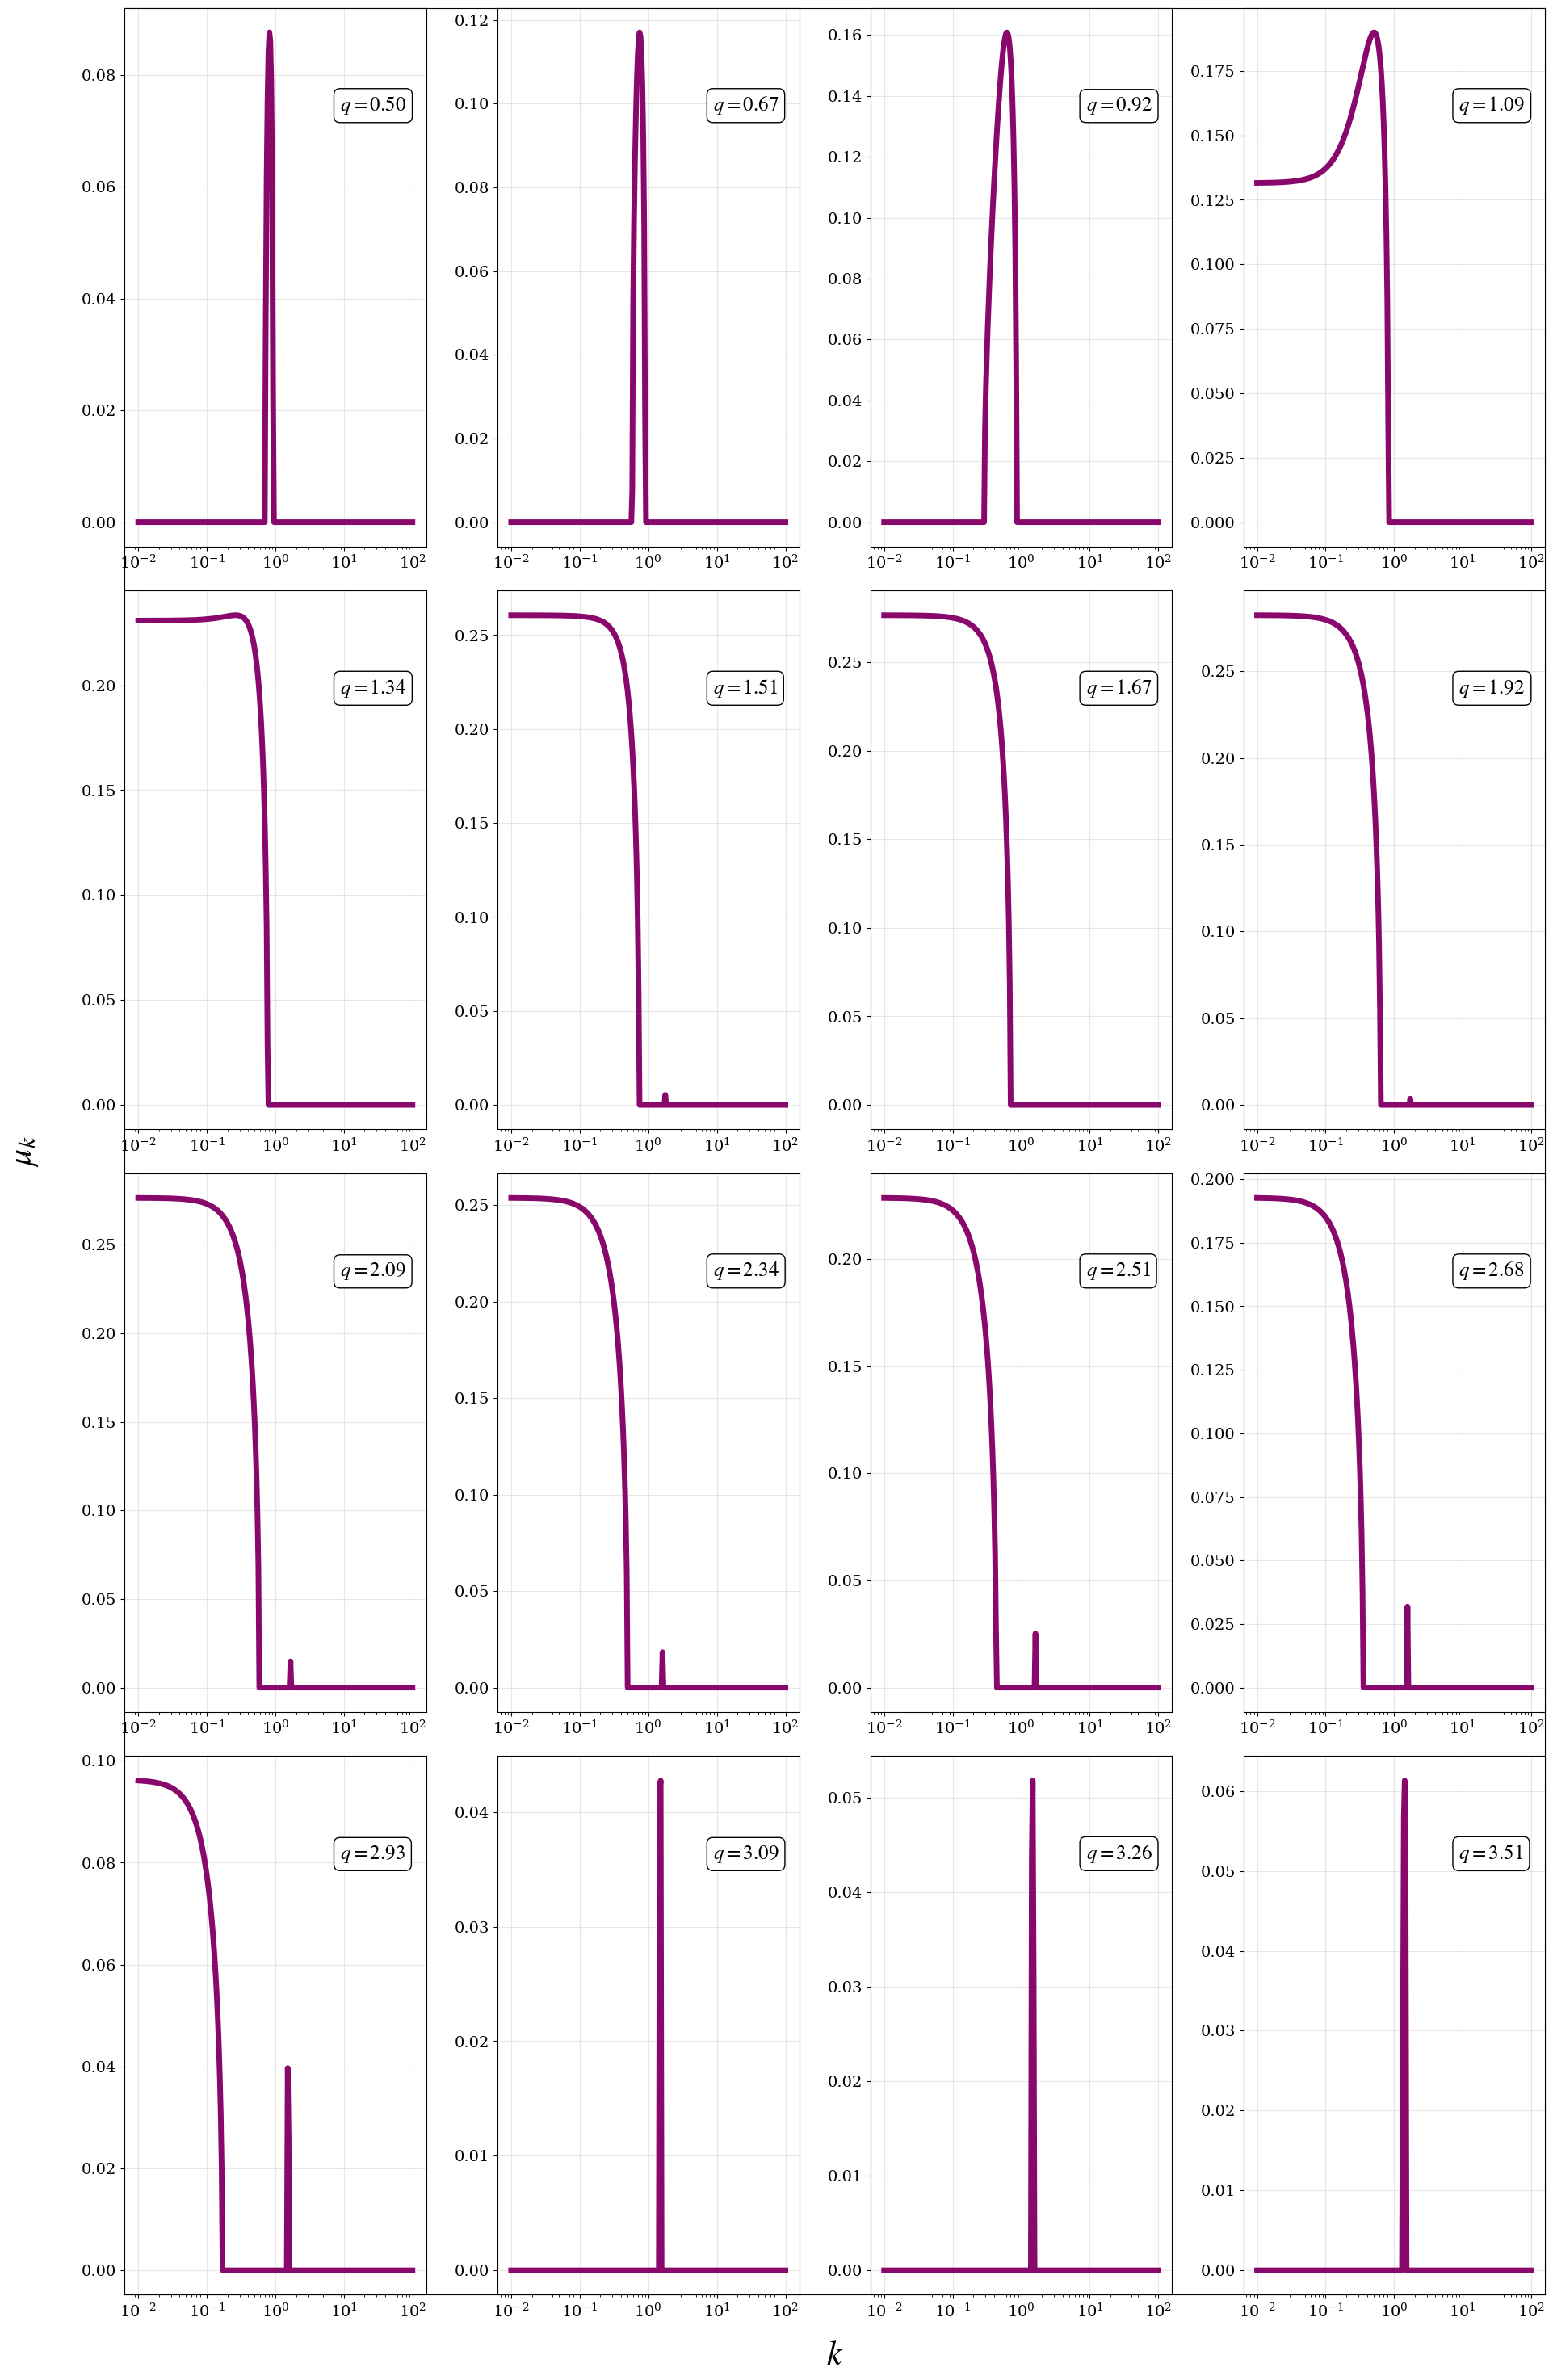

In [7]:
# Diagrama del coeficientente de Floquet en base a k para un g fijo
filename = "Floquet.csv"

data = np.loadtxt(filename, delimiter=",")
qs = data[0, 1:]
ks = data[1:, 0]
mu = data[1:, 1:]

Q = np.linspace(0.5, 3.5, 16)
i = 0

plt.figure(figsize=(20, 30))
plt.xlabel(r'$k$', fontsize=30, labelpad=40)
plt.ylabel(r'$\mu_k$', fontsize=30, labelpad=75)
plt.xticks([])
plt.yticks([])

for q in Q:
    i += 1
    index = (np.abs(qs - q)).argmin()

    plt.subplot(4, 4, i)
    plt.plot(ks, np.real(mu[:, index]), label=f'$q={q}$', lw = 5, color = "#88086c")
    ymin, ymax = plt.gca().get_ylim()
    plt.text(x=ks[-80], y=ymax*0.8, s=rf'$q = {qs[index]:.2f}$', fontsize=18, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
    plt.xscale('log')
    plt.grid(alpha = 0.3)

plt.tight_layout()
plt.show()

## Broad vs. Narrow resonance

In [8]:
"""Parámetros"""

# Narrow Resonance
qn = 0.5
kn = 0.8277856966198477

# Broad Resonance
qb = 5050
kb = 6.4686076615463275

# Condiciones iniciales
y0 = CI(kn, qn)
phi0, phi_dot0 = y0[0], y0[1]

# Tiempos
Tosc = oscilation(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)

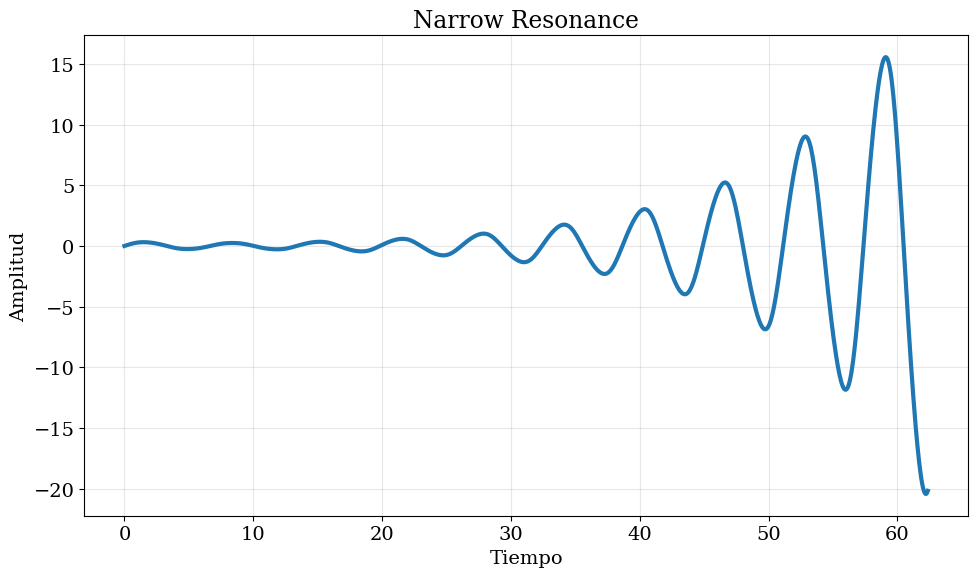

In [9]:
sol_narrow = solve_ivp(pert, t_span, y0, t_eval=np.linspace(t_span[0], t_span[-1], 1000), method='RK45', rtol=1e-6, args=(kn, qn))

plt.figure(figsize=(10, 6))
plt.plot(sol_narrow.t, sol_narrow.y[2], label=r'$\chi_k(t)$', lw = 3)
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')
plt.title(r'Narrow Resonance')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

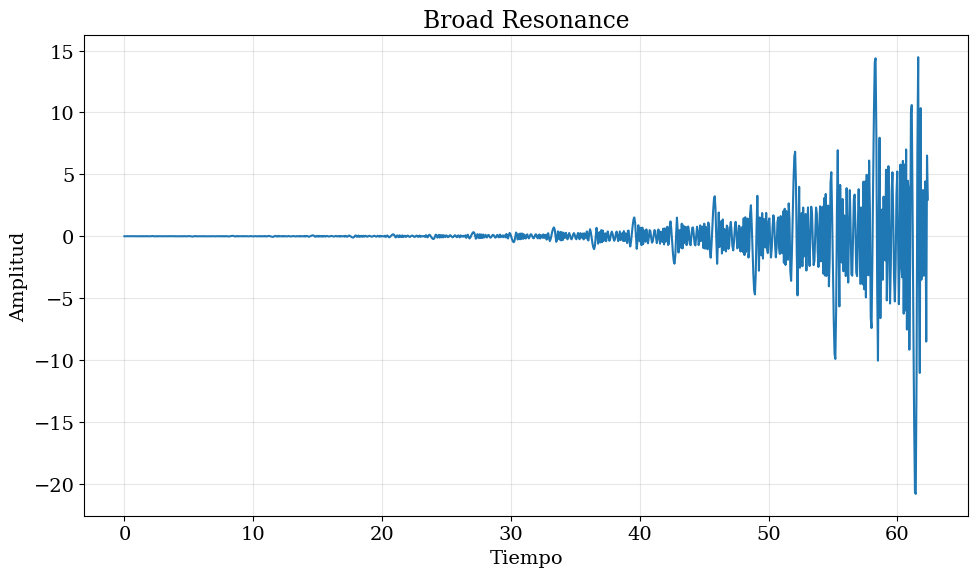

In [10]:
sol_broad = solve_ivp(pert, t_span, y0, t_eval=np.linspace(t_span[0], t_span[-1], 1000), method='RK45', rtol=1e-6, args=(kb, qb))

plt.figure(figsize=(10, 6))
plt.plot(sol_broad.t, sol_broad.y[2], label=r'$\chi_k(t)$')
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')
plt.title(r'Broad Resonance')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Número de partículas

El número de partículas del campo hijo estará dado por

$$n_\chi (k) = \frac{1}{2 \Omega_\chi} \left( \left| \frac{d \chi_k}{dT} \right|^2 + \Omega^2_\chi \left| \chi_k \right|^2 \right) - \frac{1}{2}$$

dónde

$$\Omega_\chi^2 (k, t) = \frac{k^2}{a^2} + g^2 \phi^2 (t)$$

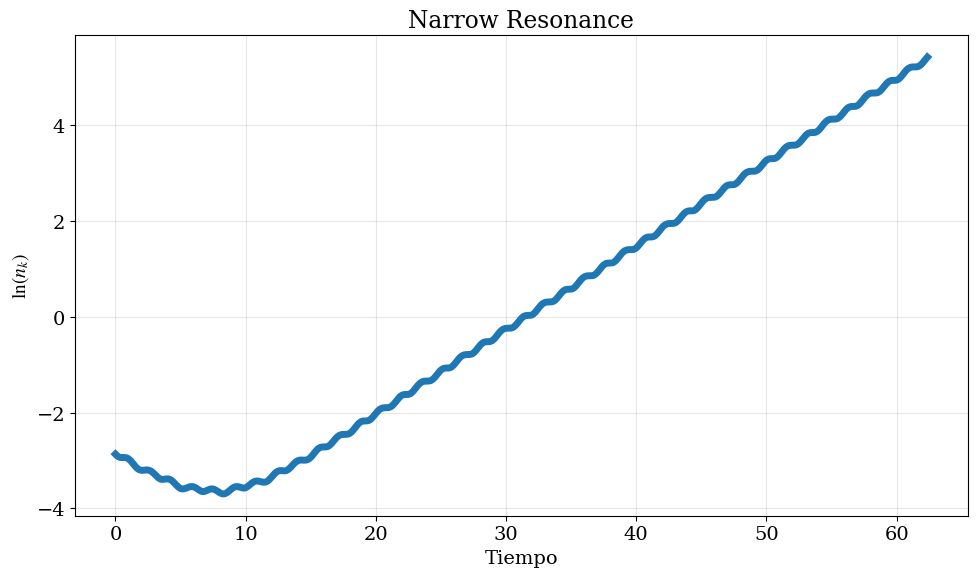

In [11]:
nk = number(kn, qn, sol_narrow.y[0], sol_narrow.y[2], sol_narrow.y[3], 1)
t = sol_narrow.t

plt.figure(figsize=(10, 6))
plt.plot(t, np.log(nk), lw = 5)
plt.xlabel('Tiempo')
plt.ylabel(r'$\ln(n_k)$')
plt.title(r'Narrow Resonance')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

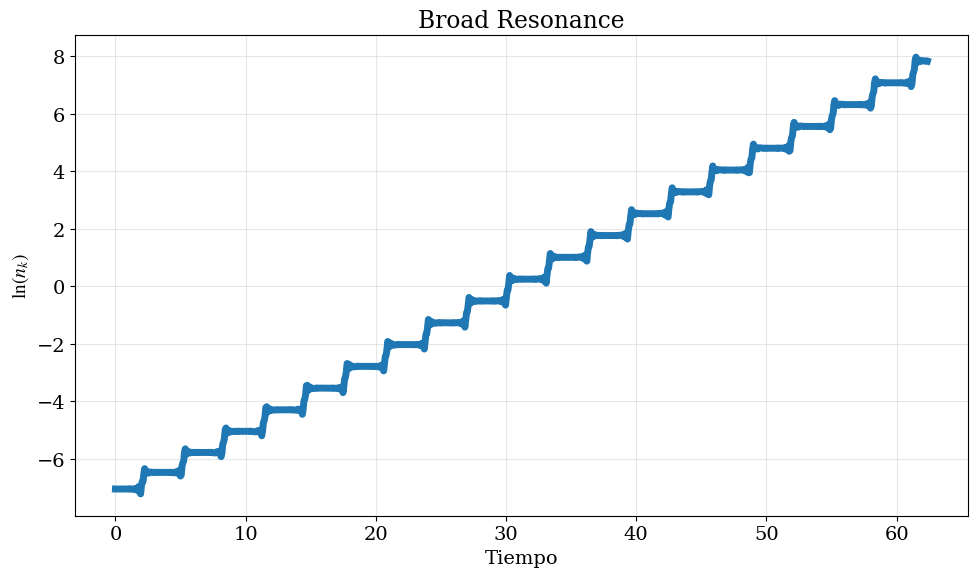

In [12]:
nk = number(kb, qb, sol_broad.y[0], sol_broad.y[2], sol_broad.y[3], 1)
t = sol_narrow.t

plt.figure(figsize=(10, 6))
plt.plot(t, np.log(nk), lw = 5)
plt.xlabel('Tiempo')
plt.ylabel(r'$\ln(n_k)$')
plt.title(r'Broad Resonance')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Dinámica con expansión

In [13]:
# Narrow Resonance
qn = 0.5
kn = 0.8277856966198477

# Broad Resonance
qb = 5050
kb = 6.4686076615463275

# Condiciones iniciales
y0_exp = CI_exp(kn, qn)
phi0, phi_dot0 = y0_exp[0], y0_exp[1]

# Tiempos
Tosc = oscilation(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)

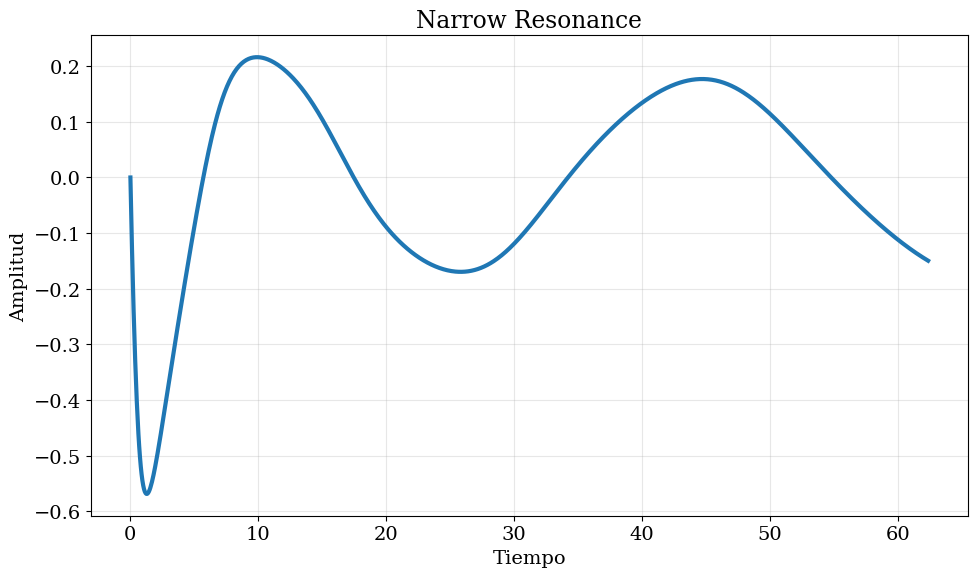

In [14]:
sol_narrow = solve_ivp(pert_exp, t_span, y0_exp, t_eval=np.linspace(t_span[0], t_span[-1], 1000), method='RK45', rtol=1e-6, args=(kn, qn))

plt.figure(figsize=(10, 6))
plt.plot(sol_narrow.t, sol_narrow.y[2], label=r'$\chi_k(t)$', lw = 3)
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')
plt.title(r'Narrow Resonance')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

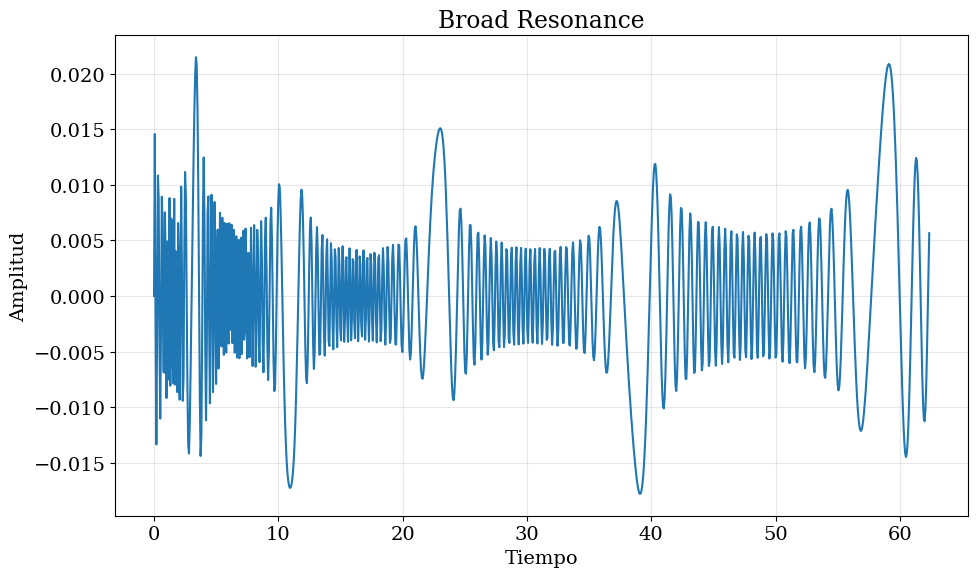

In [15]:
sol_broad = solve_ivp(pert_exp, t_span, y0_exp, t_eval=np.linspace(t_span[0], t_span[-1], 1000), method='RK45', rtol=1e-6, args=(kb, qb))

plt.figure(figsize=(10, 6))
plt.plot(sol_broad.t, sol_broad.y[2], label=r'$\chi_k(t)$')
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')
plt.title(r'Broad Resonance')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Evolución del background

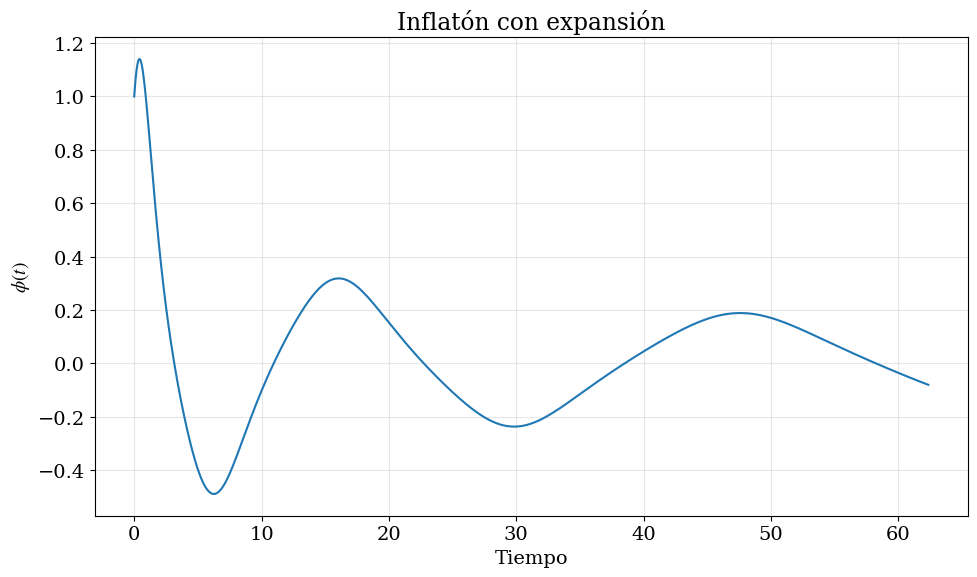

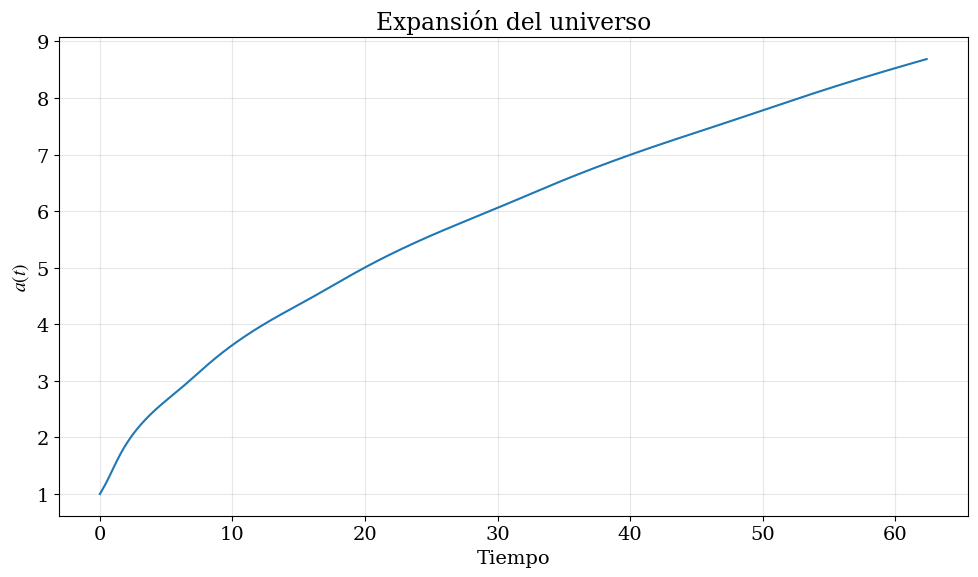

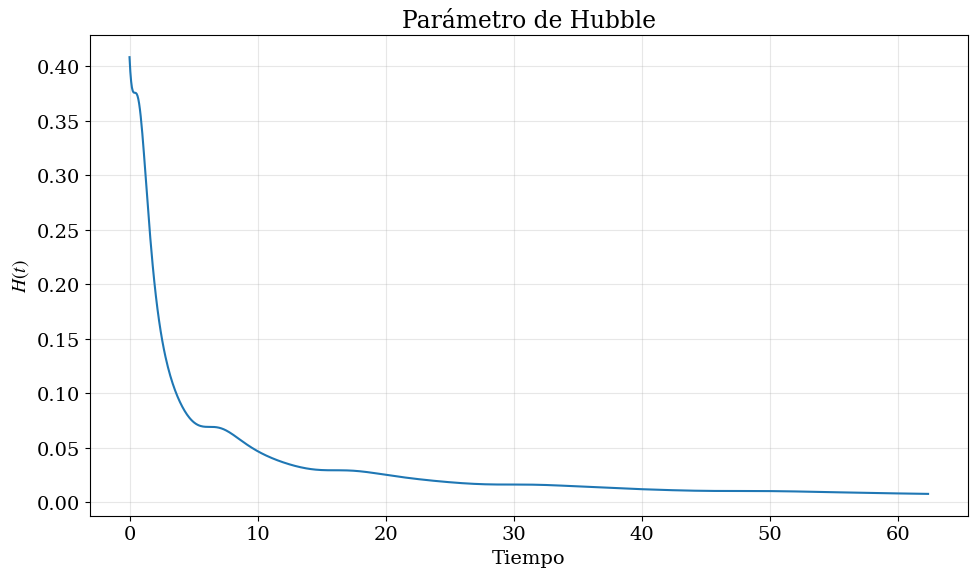

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(sol_broad.t, sol_broad.y[0], label=r'$\chi_k(t)$')
plt.xlabel('Tiempo')
plt.ylabel(r'$\phi(t)$')
plt.title(r'Inflatón con expansión')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(sol_broad.t, sol_broad.y[4], label=r'$\chi_k(t)$')
plt.xlabel('Tiempo')
plt.ylabel(r'$a(t)$')
plt.title(r'Expansión del universo')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(sol_broad.t, sol_broad.y[5]/sol_broad.y[4], label=r'$\chi_k(t)$')
plt.xlabel('Tiempo')
plt.ylabel(r'$H(t)$')
plt.title(r'Parámetro de Hubble')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Número de partículas

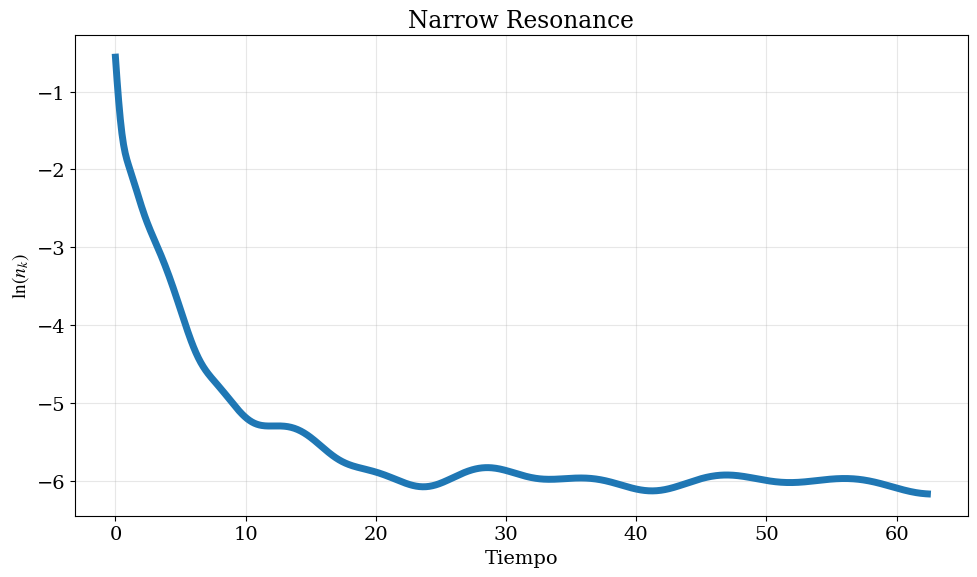

In [17]:
nk = number(kn, qn, sol_narrow.y[0], sol_narrow.y[2], sol_narrow.y[3], sol_broad.y[4])
t = sol_narrow.t

plt.figure(figsize=(10, 6))
plt.plot(t, np.log(nk), lw = 5)
plt.xlabel('Tiempo')
plt.ylabel(r'$\ln(n_k)$')
plt.title(r'Narrow Resonance')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

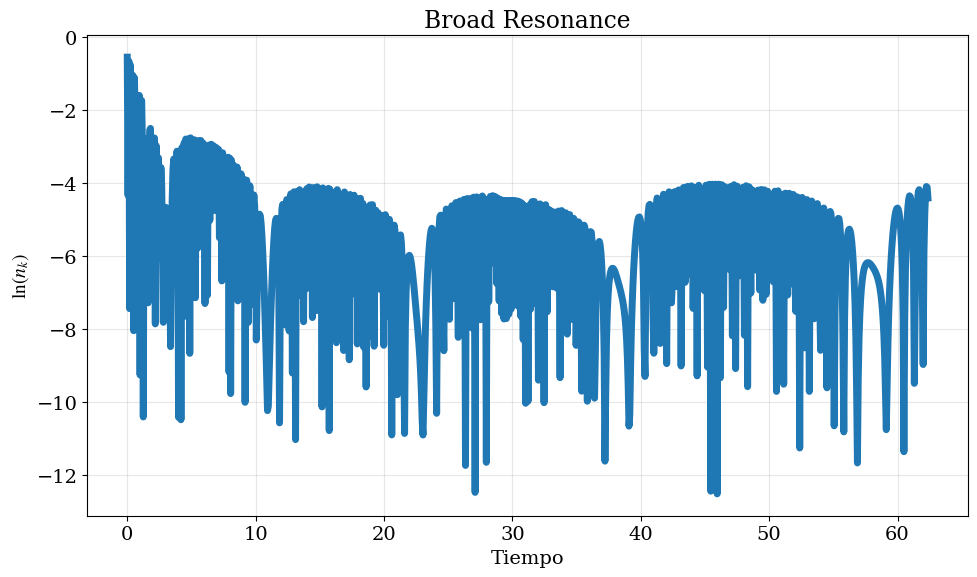

In [18]:
nk = number(kn, qn, sol_broad.y[0], sol_broad.y[2], sol_broad.y[3], sol_broad.y[4])
t = sol_narrow.t

plt.figure(figsize=(10, 6))
plt.plot(t, np.log(nk), lw = 5)
plt.xlabel('Tiempo')
plt.ylabel(r'$\ln(n_k)$')
plt.title(r'Broad Resonance')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Espectro de potencias

## Sin expansión

In [19]:
"""Parámetros"""
q = 5050
n_k = 300
ks = np.logspace(-2, 2, n_k)
chi_values = np.zeros(n_k)

# Tiempos
phi0 = 1; phi_dot0 = phi0**2/np.sqrt(2)
Tosc = oscilation(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)

In [20]:
for i, k in enumerate(tqdm(ks)):
    y0 = CI(k, q) 
    sol_k = solve_ivp(pert, t_span, y0, args=(k, q), method='RK45')
    chi_values[i] = sol_k.y[2][-1]

# Calculo P_chi para cada k usando los valores finales guardados
P_chi_vals = [Pchi(chi_val, k_val) for chi_val, k_val in zip(chi_values, ks)]

100%|██████████| 300/300 [01:42<00:00,  2.94it/s]


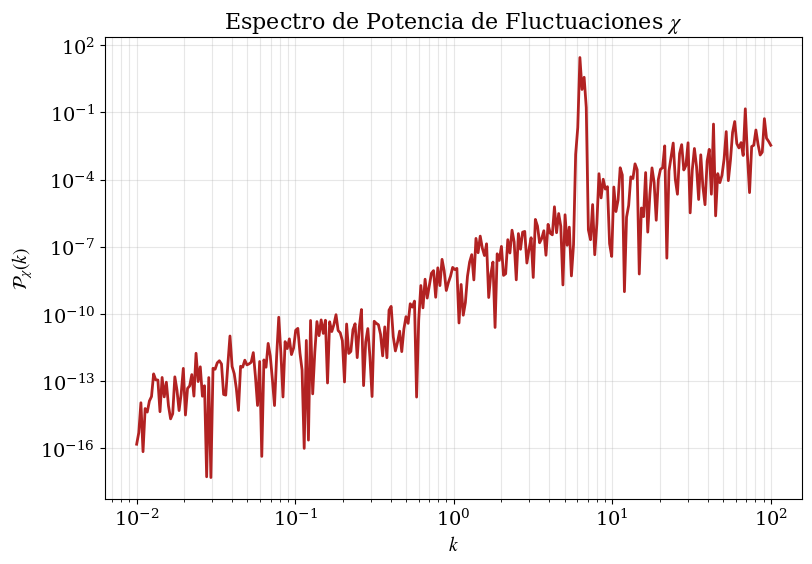

In [21]:
plt.figure(figsize=(9, 6))
plt.plot(ks, P_chi_vals, lw=2, color='firebrick')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k$', fontsize=14)
plt.ylabel(r'$\mathcal{P}_{\chi}(k)$', fontsize=14)
plt.title(r'Espectro de Potencia de Fluctuaciones $\chi$', fontsize=16)
plt.grid(True, which="both", alpha=0.3)
plt.show()

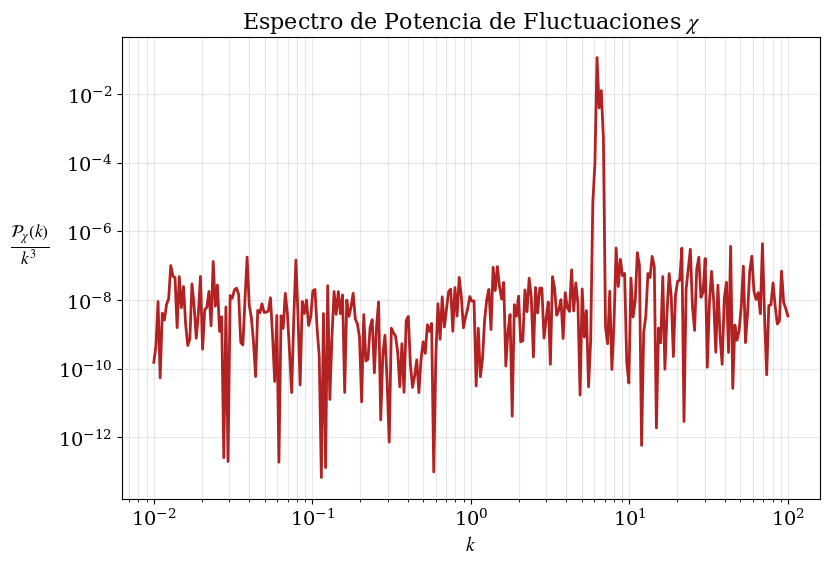

In [22]:
plt.figure(figsize=(9, 6))
plt.plot(ks, P_chi_vals/ks**3, lw=2, color='firebrick')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k$', fontsize=14)
plt.ylabel(r'$\frac{\mathcal{P}_{\chi}(k)}{k^3}$', fontsize=18, rotation='horizontal', labelpad=20)
plt.title(r'Espectro de Potencia de Fluctuaciones $\chi$', fontsize=16)
plt.grid(True, which="both", alpha=0.3)
plt.show()

## Con expansión

In [23]:
"""Parámetros"""
q = 5050
n_k = 500
ks = np.logspace(-2, 2, n_k)
chi_values = np.zeros(n_k)

# Tiempos
phi0 = 1; phi_dot0 = phi0**2/np.sqrt(2)
Tosc = oscilation(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)

In [24]:
for i, k in enumerate(tqdm(ks)):
    y0 = CI_exp(k, q) 
    sol_k = solve_ivp(pert_exp, t_span, y0, args=(k, q), method='RK45')
    chi_values[i] = sol_k.y[2][-1]

# Calculo P_chi para cada k usando los valores finales guardados
P_chi_vals = [Pchi(chi_val, k_val) for chi_val, k_val in zip(chi_values, ks)]

100%|██████████| 500/500 [00:44<00:00, 11.18it/s]


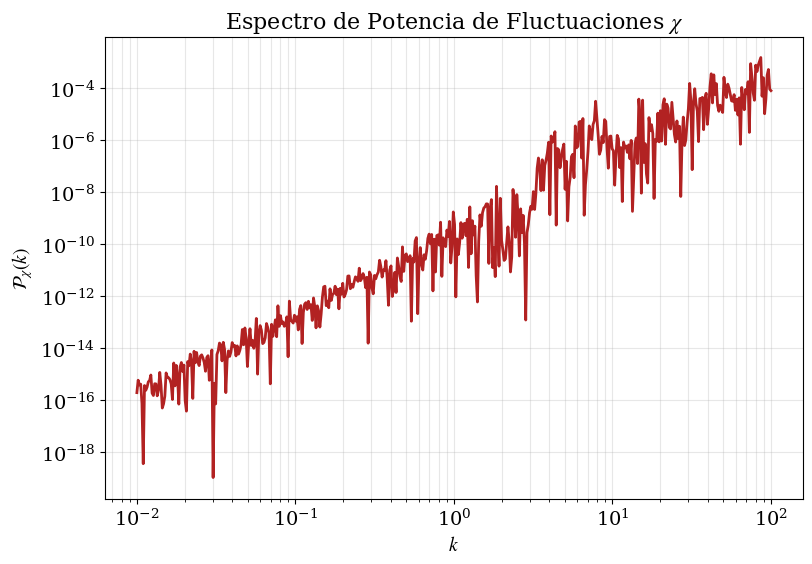

In [25]:
plt.figure(figsize=(9, 6))
plt.plot(ks, P_chi_vals, lw=2, color='firebrick')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k$', fontsize=14)
plt.ylabel(r'$\mathcal{P}_{\chi}(k)$', fontsize=14)
plt.title(r'Espectro de Potencia de Fluctuaciones $\chi$', fontsize=16)
plt.grid(True, which="both", alpha=0.3)
plt.show()

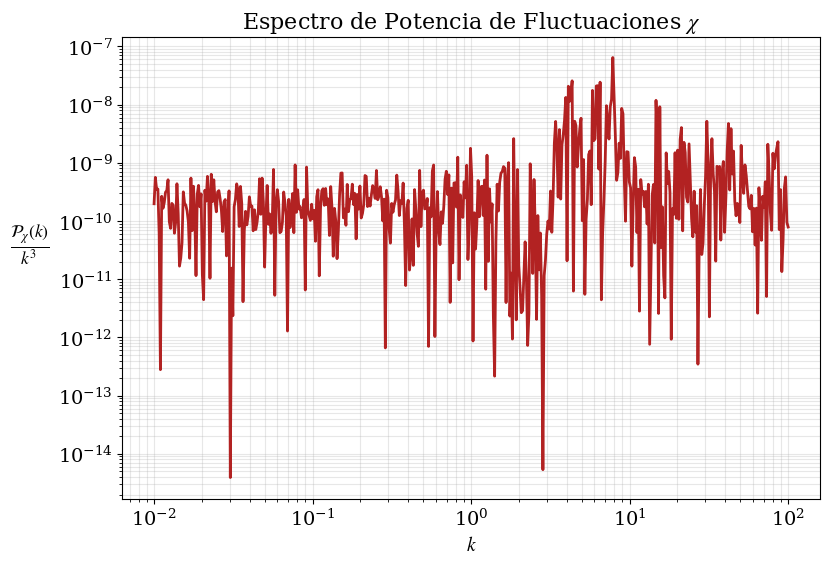

In [26]:
plt.figure(figsize=(9, 6))
plt.plot(ks, P_chi_vals/ks**3, lw=2, color='firebrick')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k$', fontsize=14)
plt.ylabel(r'$\frac{\mathcal{P}_{\chi}(k)}{k^3}$', fontsize=18, rotation='horizontal', labelpad=20)
plt.title(r'Espectro de Potencia de Fluctuaciones $\chi$', fontsize=16)
plt.grid(True, which="both", alpha=0.3)
plt.show()

# GW Production

Para poder calcular la densidad de energía de ondas gravitacionales debemos utilizar

$$\frac{d \rho_{GW}}{d \log k} = \frac{k^3}{16 \pi^4 m_p^2 a^4} \int p^6 \sin^5 \theta ~ \left[ \left| I_{(c)} (k, p, \theta, \tau)  \right|^2 + \left| I_{(s)} (k, p, \theta, \tau)  \right|^2 \right] ~ dp ~ d\theta$$

dónde $I_{(s)}$ e $I_{(c)}$ están definidas a partir de

$$I_{(c)} (k, p, \theta, \tau) = \int_{\tau_{i}}^\tau  \frac{\cos (k\tau^\prime)}{a \left( \tau^\prime \right)} ~ \chi^{(c)}_{p} (\tau^\prime) ~ \chi_{k - p}^{(c)} (\tau^\prime) ~ d\tau^\prime$$

$$I_{(s)} (k, p, \theta, \tau) = \int_{\tau_{i}}^\tau  \frac{\sin (k\tau^\prime)}{a \left( \tau^\prime \right)} ~ \chi^{(c)}_{p} (\tau^\prime) ~ \chi_{k - p}^{(c)} (\tau^\prime) ~ d\tau^\prime$$

y los $\chi_k^{(c)}$ es la dinámica del campo hijo que conseguimos previamente

Podemos plantear $x = \cos \theta$ de modo tal que la integral a resolver se escribe como

$$\frac{d \rho_{GW}}{d \log k} = \frac{k^3}{16 \pi^4 m_p^2 a^4} \int_{p_0}^{p_f} \int_{-1}^{1} p^6 \left( 1 - x^2 \right)^2 \left[ \left| I_c \left( k, p, x, t \right) \right|^2 + \left| I_s \left( k, p, x, t \right) \right|^2 \right] ~ dp ~ dx$$

In [27]:
def Is(ti, tf, y0, k, g, p, x):
    # Use a dense, fixed time grid and composite Simpson integration
    t_eval = np.linspace(ti, tf, int(1e4))

    sol_k = solve_ivp(pert, [ti, tf], y0, args=(k, g), t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-8)
    chi_k = sol_k.y[2]
    a = 1

    kp = np.sqrt(np.abs(k**2 + p**2 - 2 * k * p * x))
    sol_p = solve_ivp(pert, [ti, tf], y0, args=(kp, g), t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-8)
    chi_p = sol_p.y[2]

    # Evaluate integrand on the grid and use Simpson (more stable for oscillatory integrands)
    integrand_vals = np.sin(k * t_eval) / a * chi_k * chi_p
    try:
        Is_value = simpson(y = integrand_vals, x = t_eval)
        return Is_value
    except Exception as e:
        print(f"Error en Is (simpson): {e}")
        return 0


def Ic(ti, tf, y0, k, g, p, x):
    t_eval = np.linspace(ti, tf, int(1e4))

    sol_k = solve_ivp(pert, [ti, tf], y0, args=(k, g), t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-8)
    chi_k = sol_k.y[2]
    a = 1

    kp = np.sqrt(np.abs(k**2 + p**2 - 2 * k * p * x))
    sol_p = solve_ivp(pert, [ti, tf], y0, args=(kp, g), t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-8)
    chi_p = sol_p.y[2]

    integrand_vals = np.cos(k * t_eval) / a * chi_k * chi_p
    try:
        Ic_value = simpson(y = integrand_vals, x = t_eval)
        return Ic_value
    except Exception as e:
        print(f"Error en Ic (simpson): {e}")
        return 0

def rhoGW(ti, tf, y0, k, g, p0, pf):
    def integrand(x, p):
        Is_value = Is(ti, tf, y0, k, g, p, x)
        Ic_value = Ic(ti, tf, y0, k, g, p, x)
        return p**6 * (1 - x**2)**2 * (np.abs(Is_value)**2 + np.abs(Ic_value)**2)
    
    rhoGW_value, _ = dblquad(integrand, -1, 1, lambda x: p0, lambda x: pf)  # Nota: límites de x de -1 a 1, p de p0 a pf
    return rhoGW_value


In [30]:
# Parámetros fijos
ti, tf = 0, 100
g = 5050
p0, pf = 0, 10  
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2 / np.sqrt(2)
#a0 = 1
#a_dot0 = phi0 / np.sqrt(3)
y0 = [phi0, phi_dot0, 0, 1]#, a0, a_dot0]  # CI: phi, phi_dot, chi_k, chi_dot_k, a, a_dot

# Rango de k
k_values = np.logspace(-1, 1, 20)  
rhoGW_values = []

for k in tqdm(k_values, desc="Calculando rhoGW"):
    rho = rhoGW(ti, tf, y0, k, g, p0, pf)
    rhoGW_values.append(rho)

rhoGW_values = np.array(rhoGW_values)

Calculando rhoGW:   0%|          | 0/20 [9:13:32<?, ?it/s]


KeyboardInterrupt: 

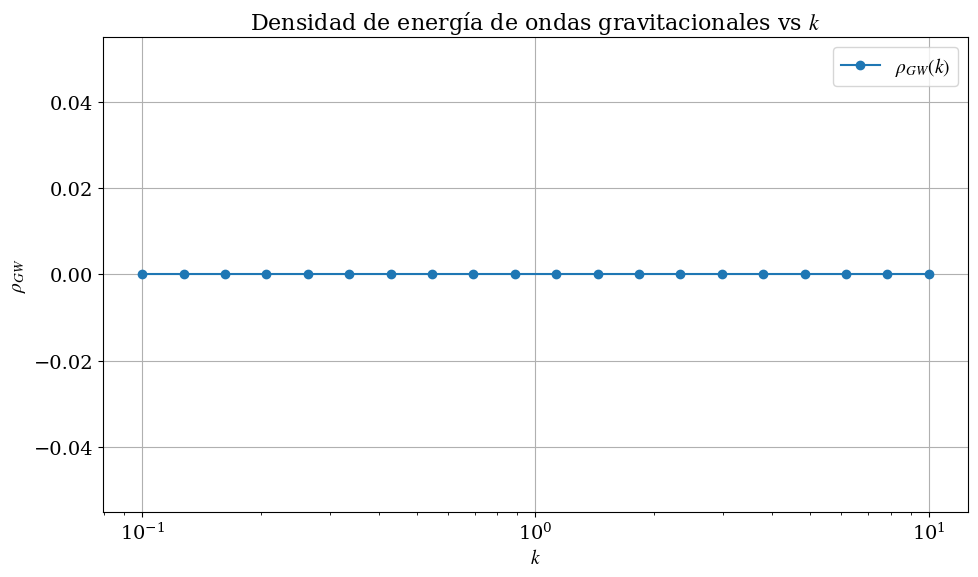

In [ ]:
# Graficar
plt.figure(figsize=(10, 6))
plt.plot(k_values, rhoGW_values, 'o-', label=r'$\rho_{GW}(k)$')
plt.xlabel(r'$k$', fontsize=14)
plt.ylabel(r'$\rho_{GW}$', fontsize=14)
plt.xscale('log')
#plt.yscale('log')
plt.title(r'Densidad de energía de ondas gravitacionales vs $k$', fontsize=16)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()